# Simulating Human Annotator Agreement and Alt-Test Performance

This notebook simulates binary responses from varying numbers of human annotators on different numbers of items at specified agreement levels. We then examine how these combinations affect simulated LLM's performance on the alt-test (win-rate, advantage probability, etc.) at different LLM accuracy rates with the majority human vote.

## Steps
1. Simulate binary human annotation data for simulated sets of pairs from a set number of items.
2. Aggregate human responses to majority/consensus label per item.
3. Simulate LLM responses based on the majority labels.
4. Run alt-test using the Pairadigm class to examine performance changes.
5. Visualize and summarize results.

In [1]:
import sys
import numpy as np
from numpy.random import SeedSequence, default_rng
import pandas as pd
from scipy.optimize import minimize_scalar
from io import StringIO
import itertools
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from pairadigm import Pairadigm
import os
import dotenv

dotenv.load_dotenv(dotenv_path='/Users/mlchrzan/Library/CloudStorage/OneDrive-Personal/Professional/Data Science/Maryland/bechmark analysis pipeline/benchmark-analysis/.env')

# np.random.seed(1234)  # Set seed for reproducibility

True

In [2]:
def simulate_pairs(num_items, pairs_per_item, rng=None):
    """
    Generate unique undirected pairs uniformly sampled from all possible combinations.
    Also generates true labels for each pair.
    
    Args:
        num_items: Total number of items
        pairs_per_item: Target number of pairs each item should appear in (approximate)
    
    Returns:
        pd.DataFrame with columns 'item1_id', 'item2_id', and 'true_label'
    """
    if rng is None:
        rng = np.random.default_rng()
        
    # Generate all possible pairs
    all_possible_pairs = list(itertools.combinations(range(num_items), 2))
    
    # Calculate number of pairs to sample
    num_pairs = int(np.floor(num_items * pairs_per_item / 2))
    
    # Ensure we don't sample more pairs than exist
    num_pairs = min(num_pairs, len(all_possible_pairs))
    
    # Randomly sample unique pairs uniformly
    sampled_pairs = [all_possible_pairs[i] for i in rng.choice(
        len(all_possible_pairs), 
        size=num_pairs, 
        replace=False
    )]
    
    # Create DataFrame with pairs
    pairs_df = pd.DataFrame(sampled_pairs, columns=['item1_id', 'item2_id'])
    
    # Generate latent scores for each item
    item_scores = rng.standard_normal(num_items)
    
    # Generate true labels for each pair (transitive: label=1 if item1 > item2, else 0)
    pairs_df['true_label'] = [
        int(item_scores[i1] > item_scores[i2]) 
        for i1, i2 in pairs_df[['item1_id', 'item2_id']].values
    ]
    
    return pairs_df

simulate_pairs(100, 10)

,item1_id,item2_id,true_label
0,1,38,1
1,21,83,1
2,32,77,1
3,21,73,0
4,69,85,0
...,...,...,...
495,12,43,0
496,12,62,1
497,38,58,0
498,26,42,1


In [3]:
# Simulate Human Annotations at a given agreement level and accuracy
def calculate_krippendorff_alpha(annotation_matrix):
    """
    Calculate Krippendorff's Alpha for binary annotations.
    
    Args:
        annotation_matrix: numpy array of shape (n_items, n_annotators)
    
    Returns:
        Krippendorff's Alpha value
    """
    n_items, n_raters = annotation_matrix.shape
    
    # Coincidence matrix for binary data
    coincidence = np.zeros((2, 2))
    
    # Count pairwise agreements/disagreements
    for i in range(n_items):
        values = annotation_matrix[i, :]
        for c1 in range(2):
            for c2 in range(2):
                n_c1 = np.sum(values == c1)
                n_c2 = np.sum(values == c2)
                if c1 == c2:
                    coincidence[c1, c2] += n_c1 * (n_c1 - 1)
                else:
                    coincidence[c1, c2] += n_c1 * n_c2
    
    # Normalize
    n_total = np.sum(coincidence)
    if n_total == 0:
        return 0.0
    
    coincidence = coincidence / n_total
    
    # Calculate observed and expected disagreement
    D_o = coincidence[0, 1] + coincidence[1, 0]
    
    n_c = coincidence.sum(axis=1)
    D_e = 2 * n_c[0] * n_c[1]
    
    if D_e == 0:
        return 1.0
    
    alpha = 1 - D_o / D_e
    return alpha

def adjust_agreement(annotations, num_annotators, target_alpha, current_alpha, rng=None):
    """
    Adjust annotator agreement to match target Krippendorff's Alpha.
    
    Strategy: If alpha is too low, copy more annotations from annotator 0.
              If alpha is too high, add more random noise.
    """
    if rng is None:
        rng = np.random.default_rng()

    n_pairs = len(annotations)
    
    # Determine adjustment direction
    if current_alpha < target_alpha:
        # Need to increase agreement - make annotators more similar
        # Find the mixing proportion that achieves target alpha
        def objective(mix_prop):
            test_annotations = annotations.copy()
            for i in range(1, num_annotators):
                # Mix between current annotations and copying from annotator 0
                for j in range(n_pairs):
                    if rng.random() < mix_prop:
                        test_annotations.loc[j, f'A{i}'] = \
                            test_annotations.loc[j, 'A0']
                
            test_alpha = calculate_krippendorff_alpha(
                test_annotations[[f'A{i}' for i in range(num_annotators)]].values
            )
            return abs(test_alpha - target_alpha)
        
        # Binary search for best mixing proportion
        result = minimize_scalar(objective, bounds=(0, 1), method='bounded')
        mix_prop = result.x
        
        # Apply the adjustment
        for i in range(1, num_annotators):
            copy_mask = rng.random(n_pairs) < mix_prop
            annotations.loc[copy_mask, f'A{i}'] = \
                annotations.loc[copy_mask, 'A0'].values
    
    else:
        # Need to decrease agreement - add more randomness
        def objective(flip_prop):
            test_annotations = annotations.copy()
            for i in range(num_annotators):
                flip_mask = rng.random(n_pairs) < flip_prop
                test_annotations.loc[flip_mask, f'A{i}'] = \
                    1 - test_annotations.loc[flip_mask, f'A{i}']
            
            test_alpha = calculate_krippendorff_alpha(
                test_annotations[[f'A{i}' for i in range(num_annotators)]].values
            )
            return abs(test_alpha - target_alpha)
        
        result = minimize_scalar(objective, bounds=(0, 0.5), method='bounded')
        flip_prop = result.x
        
        # Apply the adjustment
        for i in range(num_annotators):
            flip_mask = rng.random(n_pairs) < flip_prop
            annotations.loc[flip_mask, f'A{i}'] = \
                1 - annotations.loc[flip_mask, f'A{i}']
    
    return annotations
    
def simulate_human_annotations(pairs_df, num_annotators, human_accuracy, target_alpha, rng=None):
    """
    Simulate human annotations for pairwise comparisons with specified accuracy and agreement.
    
    Args:
        pairs_df: DataFrame with 'item1_id', 'item2_id', 'true_label' from simulate_pairs
        num_annotators: Number of human annotators
        human_accuracy: Probability that an annotator matches the true label (0-1)
        target_alpha: Target Krippendorff's Alpha agreement level (0-1)
    
    Returns:
        pd.DataFrame with original columns plus annotation columns 'annotator_0', 'annotator_1', etc.
    """
    if rng is None:
        rng = np.random.default_rng()

    n_pairs = len(pairs_df)
    
    # Build a dictionary of columns instead of assigning one-by-one
    annotations_dict = {
        'item1_id': pairs_df['item1_id'].values,
        'item2_id': pairs_df['item2_id'].values,
        'true_label': pairs_df['true_label'].values,
    }
    
    # Step 1: Generate base annotations with specified accuracy
    for i in range(num_annotators):
        annotator_labels = pairs_df['true_label'].values.copy()
        flip_mask = rng.random(n_pairs) > human_accuracy
        annotator_labels[flip_mask] = 1 - annotator_labels[flip_mask]
        annotations_dict[f'A{i}'] = annotator_labels
    
    # Create DataFrame all at once
    annotations = pd.DataFrame(annotations_dict)
    
    # Step 2: Adjust agreement to match target alpha
    current_alpha = calculate_krippendorff_alpha(
        annotations[[f'A{i}' for i in range(num_annotators)]].values
    )
    
    if not np.isclose(current_alpha, target_alpha, atol=0.01):
        annotations = adjust_agreement(
            annotations, num_annotators, target_alpha, current_alpha, rng=rng
        )
    
    return annotations

In [4]:
# Simulate LLM Annotations at a given accuracy
def simulate_llm_annotations(pairs_df, llm_accuracy, rng=None):
    """
    Simulate LLM binary annotations with a given accuracy.
    
    Args:
        pairs_df: DataFrame with 'true_label' column
        llm_accuracy: Probability that LLM matches true label
    
    Returns:
        numpy array of LLM labels
    """
    if rng is None:
        rng = np.random.default_rng()
        
    true_labels = pairs_df['true_label'].values
    num_pairs = len(pairs_df)
    llm_labels = np.where(
        rng.random(num_pairs) < llm_accuracy,
        true_labels,
        1 - true_labels
    )
    return llm_labels

In [5]:
# Generate pairs
pairs = simulate_pairs(num_items=20, pairs_per_item=10)

# Simulate annotations
annotated = simulate_human_annotations(
    pairs_df=pairs,
    num_annotators=10,
    human_accuracy=0.85,
    target_alpha=0.7
)

# Verify results
print(f"Number of pairs: {len(annotated)}")
print(f"\nFirst few rows:")
print(annotated.head())

# Calculate actual metrics
annotation_cols = [f'A{i}' for i in range(5)]
actual_alpha = calculate_krippendorff_alpha(annotated[annotation_cols].values)

accuracies = [
    np.mean(annotated[col] == annotated['true_label']) 
    for col in annotation_cols
]

print(f"\nActual Krippendorff's Alpha: {actual_alpha:.3f}")
print(f"Mean annotator accuracy: {np.mean(accuracies):.3f}")
print(f"Annotator accuracies: {[f'{a:.3f}' for a in accuracies]}")

Number of pairs: 100

First few rows:
   item1_id  item2_id  true_label  A0  A1  A2  A3  A4  A5  A6  A7  A8  A9
0        12        13           0   1   1   0   1   1   0   1   0   0   1
1        13        14           0   0   0   0   0   0   0   0   0   0   0
2         3         5           1   0   0   0   1   0   1   0   0   0   0
3         3        19           1   1   1   1   1   0   1   1   1   1   1
4         6        17           0   0   0   0   0   0   0   0   0   0   0

Actual Krippendorff's Alpha: 0.758
Mean annotator accuracy: 0.860
Annotator accuracies: ['0.850', '0.860', '0.850', '0.920', '0.820']


In [6]:
num_items=32
pairs_per_item=5
num_annotators=5
llm_accuracy=0.1
human_accuracy=0.9
target_alpha=-0.8
epsilon=0.0

# Simulate paired items with true labels
pairs = simulate_pairs(num_items, pairs_per_item)

# Simulate human annotations of pairs
df = simulate_human_annotations(pairs, num_annotators, human_accuracy, target_alpha)

# Simulate LLM annotations of pairs 
llm_labels = simulate_llm_annotations(pairs, llm_accuracy)

# Add LLM annotations to dataframe
df['decision_llm'] = llm_labels
df['decision_llm'] = df['decision_llm'].map({0: 'Text1', 1: 'Text2'})

# Create Pairadigm object
pairadigm_obj = Pairadigm(
    data=df, 
    item_id_cols=['item1_id', 'item2_id'],
    item_text_cols=['item1_id', 'item2_id'],
    paired=True, 
    annotated=True, 
    annotator_cols=[f'A{i}' for i in range(num_annotators)],
    cgcot_prompts=["promtpt1", "prompt2"],
    llm_annotator_cols='decision_llm',
    api_key=os.getenv('OPENAI_API_KEY'),
    model_name='gpt-5',
    target_concept='simulation'
)

pairadigm_obj.alt_test(epsilon=epsilon)

Using LLM decision column: decision_llm
Using LLM decision column: decision_llm

ALT-TEST RESULTS - LLM
Winning Rate (ω): 0.000
Advantage Probability: 0.556
Tested against 5 human annotators



(0.0, 0.55625)

In [7]:
def run_alt_test_simulation(num_items=50, pairs_per_item=10, num_annotators=3, 
                            llm_accuracy=0.8, human_accuracy=0.8,
                            target_alpha=0.8, epsilon=0.1,
                            rng=None):
    
    if rng is None:
        rng = np.random.default_rng()
    
    # Check that the pairs_per_item is feasible
    max_pairs_per_item = num_items - 1
    if pairs_per_item > max_pairs_per_item:
        pairs_per_item = max_pairs_per_item
        print(f"Adjusted pairs_per_item to {pairs_per_item} for {num_items} items to be feasible.")
    
    # NOTE: DO NOT reseed here — seeding inside the function breaks parallel runs
    # if random_seed is None:
    #     np.random.seed(1234)  # For reproducibility
    
    # Simulate paired items with true labels
    pairs = simulate_pairs(num_items, pairs_per_item)

    # Simulate human annotations of pairs
    df = simulate_human_annotations(pairs, num_annotators, human_accuracy, target_alpha)

    # Simulate LLM annotations of pairs 
    llm_labels = simulate_llm_annotations(df, llm_accuracy)
    
    # Add LLM annotations to dataframe
    df['decision_llm'] = llm_labels
    df['decision_llm'] = df['decision_llm'].map({0: 'Text1', 1: 'Text2'})
    
    # Create Pairadigm object
    pairadigm_obj = Pairadigm(
        data=df, 
        item_id_cols=['item1_id', 'item2_id'],
        item_text_cols=['item1_id', 'item2_id'],
        paired=True, 
        annotated=True, 
        annotator_cols=[f'A{i}' for i in range(num_annotators)],
        cgcot_prompts=["promtpt1", "prompt2"],
        llm_annotator_cols='decision_llm',
        api_key=os.getenv('OPENAI_API_KEY'),
        model_name='gpt-5',
        target_concept='simulation'
    )
    
    # Run alt-test
    # Suppress alt_test text output
    old_stdout = sys.stdout
    sys.stdout = StringIO()
    
    try:
        result_tuple = pairadigm_obj.alt_test(epsilon=epsilon)
    finally:
        sys.stdout = old_stdout

    # Convert tuple to dict
    result = {
        'win_rate': result_tuple[0],
        'advantage_prob': result_tuple[1]
    }

    # Calculate actual metrics
    annotation_cols = [f'A{i}' for i in range(5)]
    actual_alpha = calculate_krippendorff_alpha(annotated[annotation_cols].values)

    accuracies = [
        np.mean(annotated[col] == annotated['true_label']) 
        for col in annotation_cols
    ]

    # Append actual metrics to result
    result['actual_human_agreement'] = actual_alpha
    result['mean_human_accuracy'] = np.mean(accuracies)
    result['std_human_accuracy'] = np.std(accuracies)
    result['min_human_accuracy'] = np.min(accuracies)
    result['max_human_accuracy'] = np.max(accuracies)
    result['human_accuracies'] = accuracies

    return result

run_alt_test_simulation(num_items=35, pairs_per_item=5, num_annotators=5, 
                        llm_accuracy=0.1, human_accuracy=0.9,
                        target_alpha=-0.8, epsilon=0.0)

{'win_rate': 0.0,
 'advantage_prob': 0.6941176470588235,
 'actual_human_agreement': np.float64(0.7581134488922416),
 'mean_human_accuracy': np.float64(0.86),
 'std_human_accuracy': np.float64(0.032863353450309996),
 'min_human_accuracy': np.float64(0.82),
 'max_human_accuracy': np.float64(0.92),
 'human_accuracies': [np.float64(0.85),
  np.float64(0.86),
  np.float64(0.85),
  np.float64(0.92),
  np.float64(0.82)]}

In [8]:
# Simulation parameters
num_items_list = [50, 100, 250, 500]
num_pairs_per_item_list = [5, 10, 15, 20]
num_annotators_list = [5, 10, 30, 50, 100, 500]
llm_accuracy_levels = [0.1, 0.25, 0.5, 0.75, 0.9]
human_accuracy_levels = [0.1, 0.25, 0.5, 0.75, 0.9]
target_alpha_levels = [0.0, 0.5, 0.9]
epsilon_levels = [0.0, 0.10, 0.15, 0.2]

# Total combinations
total_combinations = (len(num_items_list) * len(num_pairs_per_item_list) * 
                      len(num_annotators_list) * len(llm_accuracy_levels) * 
                      len(target_alpha_levels) * len(human_accuracy_levels) *
                      len(epsilon_levels))
print(f"Total simulation combinations: {total_combinations}")

Total simulation combinations: 28800


In [9]:
# # Run simulations in parallel (to use all CPU cores set n_jobs=-1)

# # Wrap the parameter combinations with tqdm for progress monitoring
# param_combinations = [
#     (num_items, num_pairs_per_item, num_annotators, llm_accuracy, human_accuracy, target_alpha, epsilon)
#     for num_items in num_items_list
#     for num_pairs_per_item in num_pairs_per_item_list
#     for num_annotators in num_annotators_list
#     for llm_accuracy in llm_accuracy_levels
#     for human_accuracy in human_accuracy_levels
#     for target_alpha in target_alpha_levels
#     for epsilon in epsilon_levels
# ]

# # Use tqdm to monitor progress in parallel execution
# results_list = Parallel(n_jobs=28)(
#     delayed(run_alt_test_simulation)(*params) for params in tqdm(param_combinations, desc="Simulations Progress")
# )

# results = [
#     {
#         'num_items': params[0],
#         'num_pairs_per_item': params[1],
#         'num_annotators': params[2],
#         'llm_accuracy': params[3],
#         'human_accuracy': params[4],
#         'target_alpha': params[5],
#         'epsilon': params[6],
#         'win_rate': res['win_rate'],
#         'advantage_prob': res['advantage_prob'],
#         'agreement_achieved': res['actual_human_agreement'],
#         'mean_human_accuracy': res['mean_human_accuracy'],
#         'std_human_accuracy': res['std_human_accuracy'],
#         'min_human_accuracy': res['min_human_accuracy'],
#         'max_human_accuracy': res['max_human_accuracy'],
#         'human_accuracies': res['human_accuracies']
#     }
#     for params, res in zip(param_combinations, results_list)
# ]
# results_df = pd.DataFrame(results)

In [10]:
# Run simulations in parallel (to use all CPU cores set n_jobs=-1)

# Wrap the parameter combinations with tqdm for progress monitoring
param_combinations = [
    (num_items, num_pairs_per_item, num_annotators, llm_accuracy, human_accuracy, target_alpha, epsilon)
    for num_items in num_items_list
    for num_pairs_per_item in num_pairs_per_item_list
    for num_annotators in num_annotators_list
    for llm_accuracy in llm_accuracy_levels
    for human_accuracy in human_accuracy_levels
    for target_alpha in target_alpha_levels
    for epsilon in epsilon_levels
]

# Base seed for reproducibility
ss = SeedSequence(12345)

# Spawn child seeds for each parameter combination
child_seeds = ss.spawn(len(param_combinations))

# Create RNGs
rngs = [default_rng(s) for s in child_seeds]

results_list = Parallel(n_jobs=8)(
    delayed(run_alt_test_simulation)(*params, rng=rngs[i])
    for i, params in enumerate(tqdm(param_combinations, desc="Simulations Progress"))
)

results = [
    {
        'num_items': params[0],
        'num_pairs_per_item': params[1],
        'num_annotators': params[2],
        'llm_accuracy': params[3],
        'human_accuracy': params[4],
        'target_alpha': params[5],
        'epsilon': params[6],
        'win_rate': res['win_rate'],
        'advantage_prob': res['advantage_prob'],
        'agreement_achieved': res['actual_human_agreement'],
        'mean_human_accuracy': res['mean_human_accuracy'],
        'std_human_accuracy': res['std_human_accuracy'],
        'min_human_accuracy': res['min_human_accuracy'],
        'max_human_accuracy': res['max_human_accuracy'],
        'human_accuracies': res['human_accuracies']
    }
    for params, res in zip(param_combinations, results_list)
]
results_df = pd.DataFrame(results)

Simulations Progress:   9%|▉         | 2608/28800 [14:05<1:39:34,  4.38it/s] /Users/mlchrzan/opt/anaconda3/envs/pairadigm/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
Simulations Progress:  11%|█         | 3072/28800 [16:51<5:03:16,  1.41it/s]/Users/mlchrzan/opt/anaconda3/envs/pairadigm/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
Simulations Progress:  11%|█         | 3080/28800 [16:52<3:51:22,  1.85it/s]/Users/mlchrzan/opt/anaconda3/envs/pairadigm/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWar

In [12]:
results_df.to_csv('alt_test_simulation_results.csv', index=False)

In [ ]:
# results_df = pd.read_csv('alt_test_simulation_results.csv')

In [11]:
results_df

,num_items,num_pairs_per_item,num_annotators,llm_accuracy,human_accuracy,target_alpha,epsilon,win_rate,advantage_prob,agreement_achieved,mean_human_accuracy,std_human_accuracy,min_human_accuracy,max_human_accuracy,human_accuracies
0,50,5,5,0.1,0.1,0.0,0.00,0.0,0.716000,0.758113,0.86,0.032863,0.82,0.92,"[0.85, 0.86, 0.85, 0.92, 0.82]"
1,50,5,5,0.1,0.1,0.0,0.10,0.0,0.704000,0.758113,0.86,0.032863,0.82,0.92,"[0.85, 0.86, 0.85, 0.92, 0.82]"
2,50,5,5,0.1,0.1,0.0,0.15,0.0,0.728000,0.758113,0.86,0.032863,0.82,0.92,"[0.85, 0.86, 0.85, 0.92, 0.82]"
3,50,5,5,0.1,0.1,0.0,0.20,0.0,0.695833,0.758113,0.86,0.032863,0.82,0.92,"[0.85, 0.86, 0.85, 0.92, 0.82]"
4,50,5,5,0.1,0.1,0.5,0.00,0.0,0.760000,0.758113,0.86,0.032863,0.82,0.92,"[0.85, 0.86, 0.85, 0.92, 0.82]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28795,500,20,500,0.9,0.9,0.5,0.20,1.0,0.632380,0.758113,0.86,0.032863,0.82,0.92,"[0.85, 0.86, 0.85, 0.92, 0.82]"
28796,500,20,500,0.9,0.9,0.9,0.00,0.0,0.341916,0.758113,0.86,0.032863,0.82,0.92,"[0.85, 0.86, 0.85, 0.92, 0.82]"
28797,500,20,500,0.9,0.9,0.9,0.10,0.0,0.332408,0.758113,0.86,0.032863,0.82,0.92,"[0.85, 0.86, 0.85, 0.92, 0.82]"
28798,500,20,500,0.9,0.9,0.9,0.15,0.0,0.334512,0.758113,0.86,0.032863,0.82,0.92,"[0.85, 0.86, 0.85, 0.92, 0.82]"


In [13]:
# Check results_df for non-numeric (non-convertible) values
def check_non_numeric(df):
    problems = []
    for col in df.columns:
        conv = pd.to_numeric(df[col], errors='coerce')
        mask = conv.isna() & ~df[col].isna()
        if mask.any():
            sample_vals = df.loc[mask, col].head(10).tolist()
            sample_idx = df.loc[mask].index[:10].tolist()
            problems.append({
                'column': col,
                'n_issues': int(mask.sum()),
                'sample_indices': sample_idx,
                'sample_values': sample_vals
            })
    return problems

problems = check_non_numeric(results_df)

if not problems:
    print("No non-numeric (non-convertible) values found in results_df.")
else:
    print(f"Found non-numeric entries in {len(problems)} column(s):")
    for p in problems:
        print(f"- {p['column']}: {p['n_issues']} problematic cells. Sample indices {p['sample_indices']}, sample values {p['sample_values']}")

# Build a DataFrame of problematic cells (row, column, value) for inspection
rows = []
for col in results_df.columns:
    conv = pd.to_numeric(results_df[col], errors='coerce')
    mask = conv.isna() & ~results_df[col].isna()
    for idx in results_df.index[mask]:
        rows.append({'index': idx, 'column': col, 'value': results_df.at[idx, col]})

problem_cells_df = pd.DataFrame(rows)
# show up to first 50 problem cells (empty if none)
problem_cells_df.head(50)

Found non-numeric entries in 1 column(s):
- human_accuracies: 28800 problematic cells. Sample indices [0, 1, 2, 3, 4, 5, 6, 7, 8, 9], sample values [[np.float64(0.85), np.float64(0.86), np.float64(0.85), np.float64(0.92), np.float64(0.82)], [np.float64(0.85), np.float64(0.86), np.float64(0.85), np.float64(0.92), np.float64(0.82)], [np.float64(0.85), np.float64(0.86), np.float64(0.85), np.float64(0.92), np.float64(0.82)], [np.float64(0.85), np.float64(0.86), np.float64(0.85), np.float64(0.92), np.float64(0.82)], [np.float64(0.85), np.float64(0.86), np.float64(0.85), np.float64(0.92), np.float64(0.82)], [np.float64(0.85), np.float64(0.86), np.float64(0.85), np.float64(0.92), np.float64(0.82)], [np.float64(0.85), np.float64(0.86), np.float64(0.85), np.float64(0.92), np.float64(0.82)], [np.float64(0.85), np.float64(0.86), np.float64(0.85), np.float64(0.92), np.float64(0.82)], [np.float64(0.85), np.float64(0.86), np.float64(0.85), np.float64(0.92), np.float64(0.82)], [np.float64(0.85), np.f

,index,column,value
0,0,human_accuracies,"[0.85, 0.86, 0.85, 0.92, 0.82]"
1,1,human_accuracies,"[0.85, 0.86, 0.85, 0.92, 0.82]"
2,2,human_accuracies,"[0.85, 0.86, 0.85, 0.92, 0.82]"
3,3,human_accuracies,"[0.85, 0.86, 0.85, 0.92, 0.82]"
4,4,human_accuracies,"[0.85, 0.86, 0.85, 0.92, 0.82]"
5,5,human_accuracies,"[0.85, 0.86, 0.85, 0.92, 0.82]"
6,6,human_accuracies,"[0.85, 0.86, 0.85, 0.92, 0.82]"
7,7,human_accuracies,"[0.85, 0.86, 0.85, 0.92, 0.82]"
8,8,human_accuracies,"[0.85, 0.86, 0.85, 0.92, 0.82]"
9,9,human_accuracies,"[0.85, 0.86, 0.85, 0.92, 0.82]"


In [ ]:
# Simulation parameters
# num_items_list = [30, 50, 100, 250, 500]
# num_pairs_per_item_list = [5, 10, 15, 20]
# num_annotators_list = [5, 10, 30, 50, 100, 500]
# llm_accuracy_levels = [0.0, 0.25, 0.5, 0.75, 1.0]
# human_accuracy_levels = [0.0, 0.25, 0.5, 0.75, 1.0]
# target_alpha_list = [0.3, 0.6, 0.9]
# epsilon_levels = [0.0, 0.10, 0.15, 0.2]
# outcomes: win_rate, advantage_prob

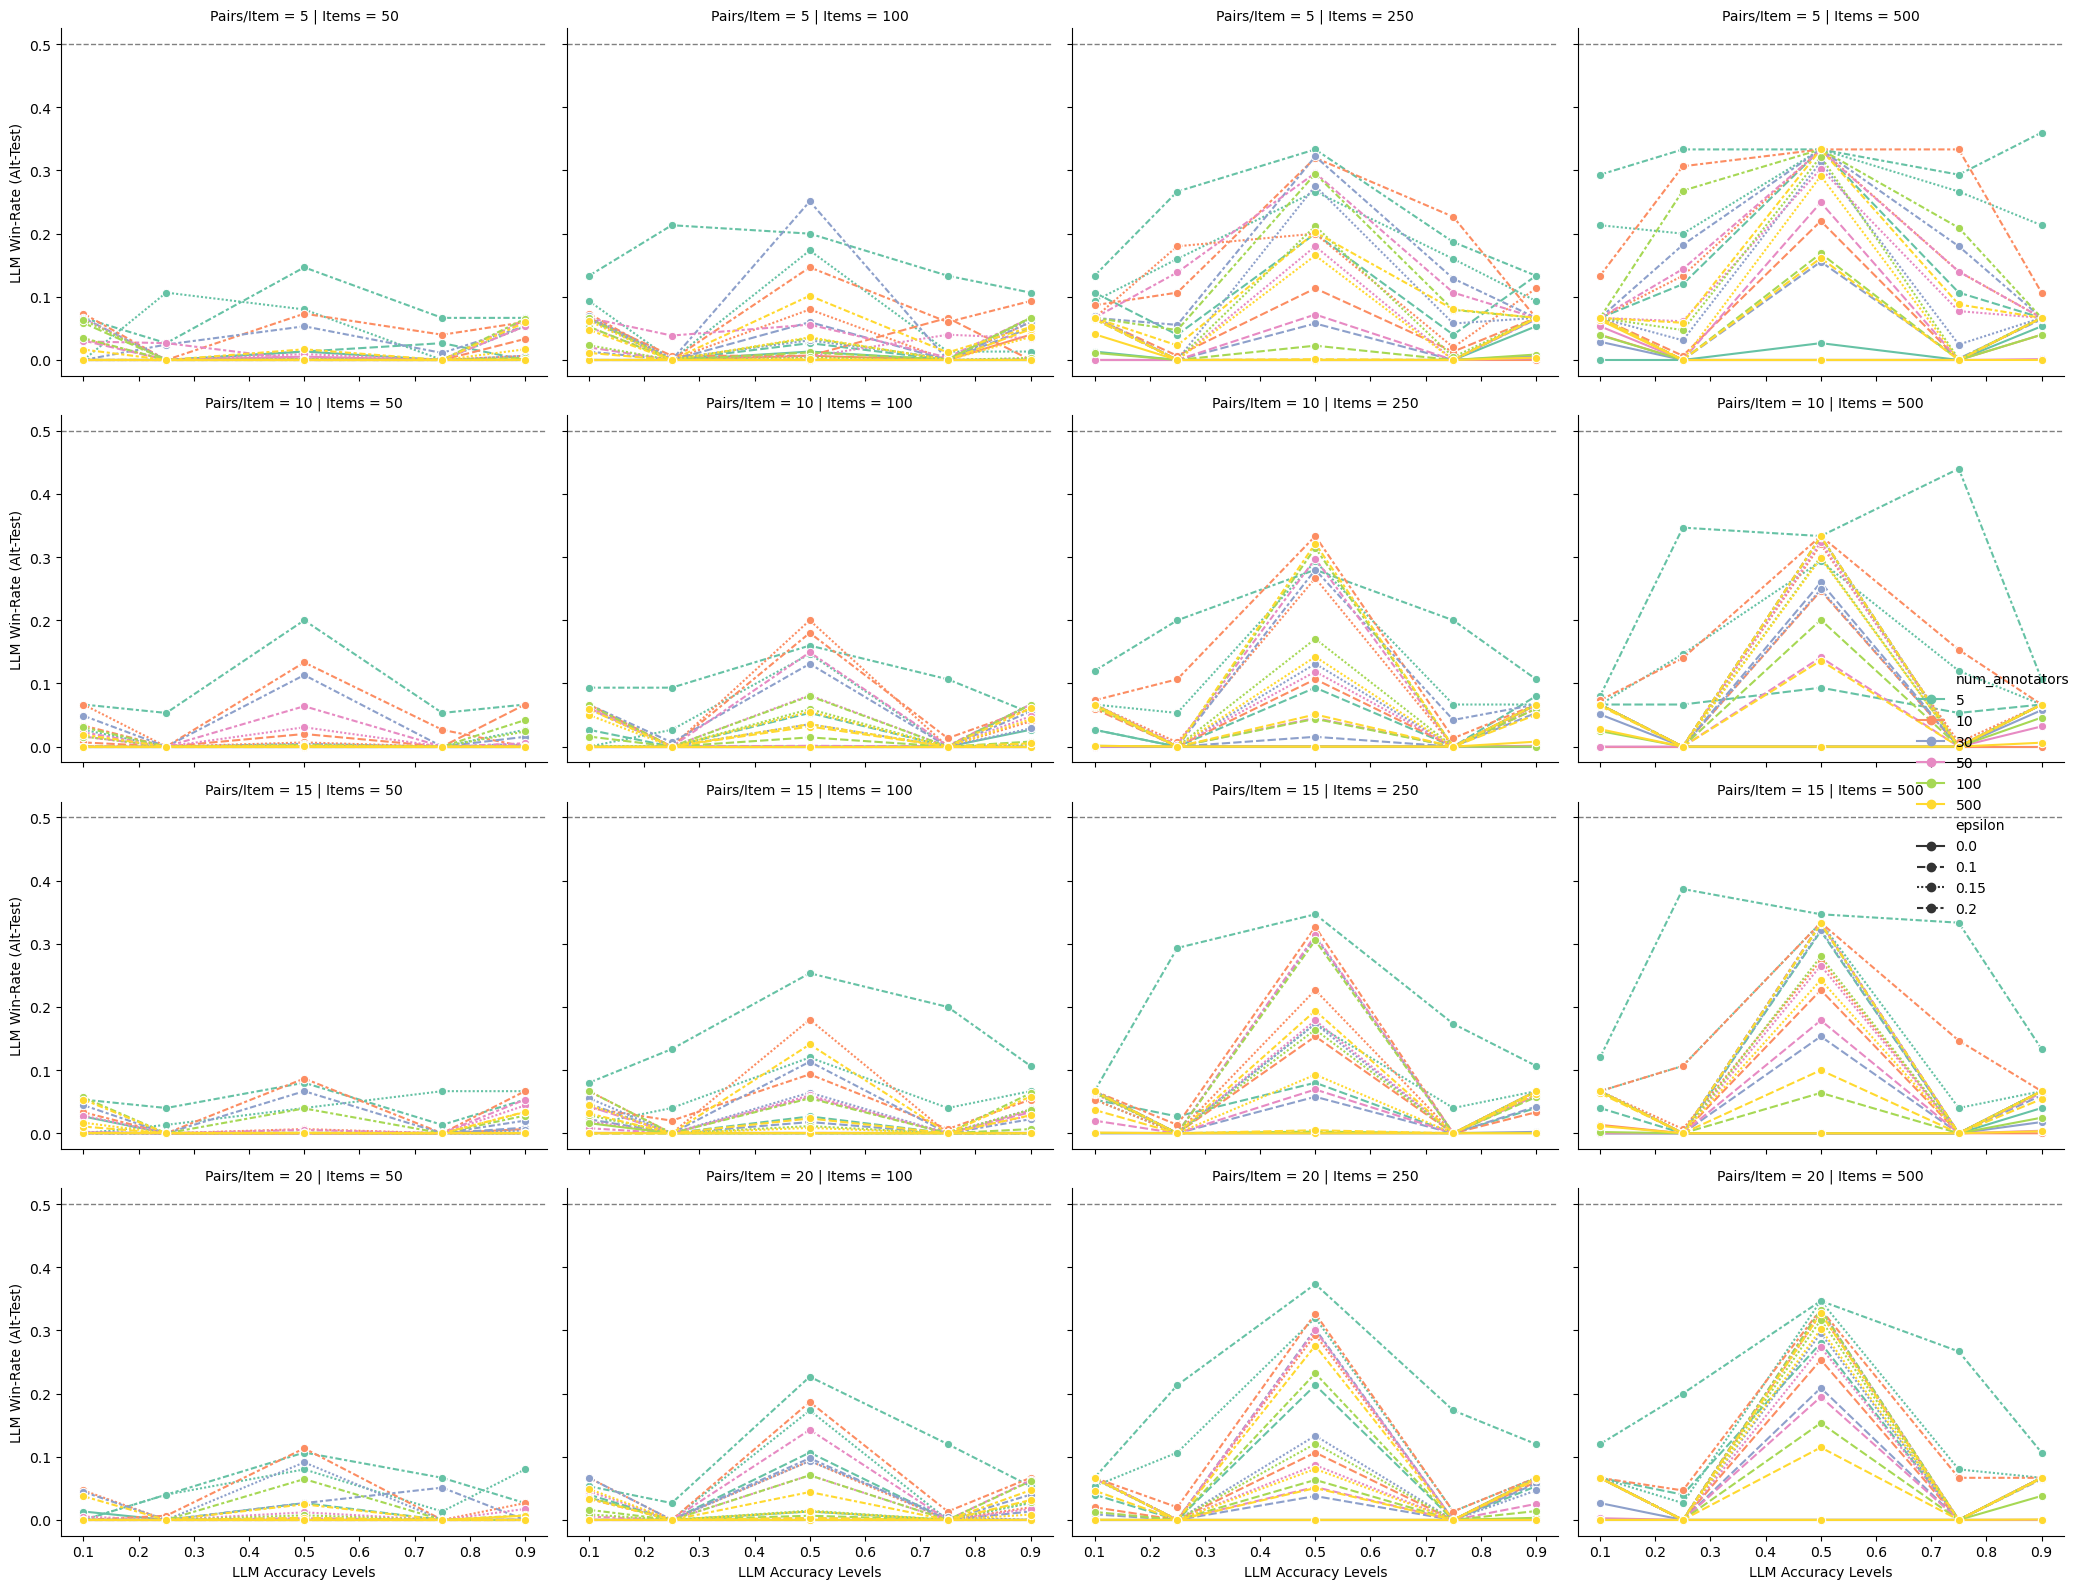

In [14]:
# Plot the relationship between LLM accuracy levels and win_rate
g = sns.relplot(
    data=results_df, 
    x='llm_accuracy', 
    y='win_rate', 
    hue='num_annotators', 
    col='num_items',
    row='num_pairs_per_item',
    kind='line',
    style='epsilon',
    marker='o',
    palette='Set2',
    errorbar=None,
    height=4,
    aspect=1.2
)
g.set_titles(col_template='Items = {col_name}', row_template='Pairs/Item = {row_name}')
g.set_axis_labels('LLM Accuracy Levels', 'LLM Win-Rate (Alt-Test)')

# Add a horizontal dashed line at y=0.5
for ax in g.axes.flat:
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

Insights:
- The more items you have, the more annotators you need
- Number of pairs per item matters less than number of items

In [16]:
llm_accuracy_fixed = 0.9

plot_data = results_df[
    (results_df['llm_accuracy'] == llm_accuracy_fixed)
]

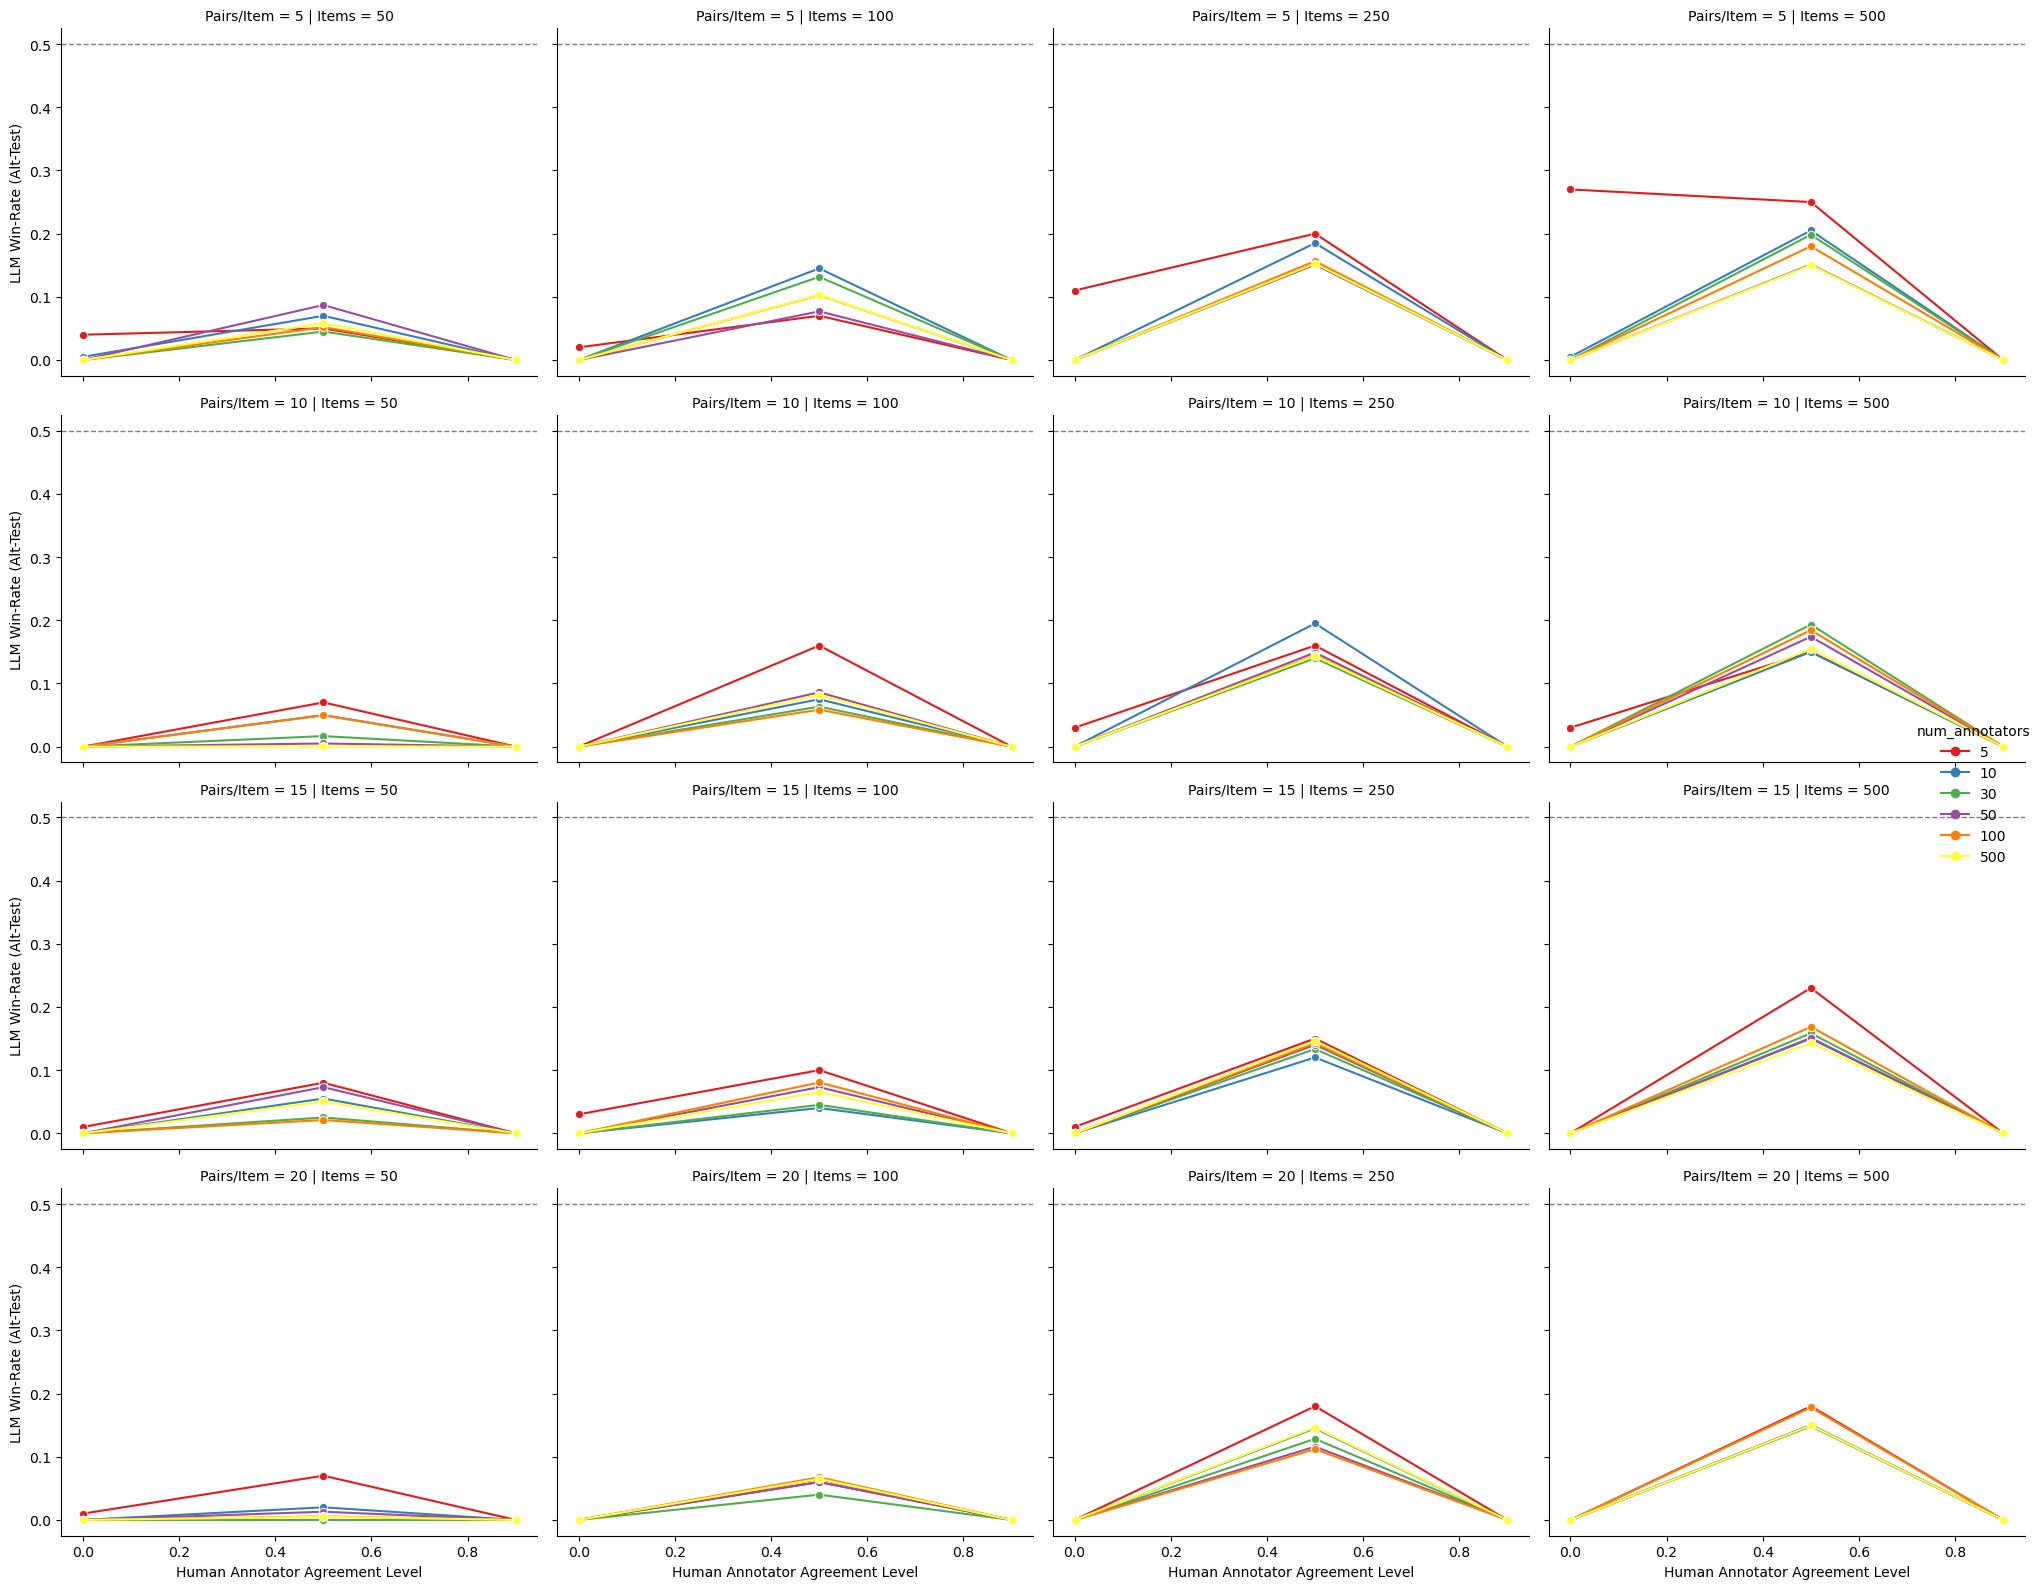

In [18]:
# Win-rate plot with 2D facets: num_items (columns) x num_pairs_per_item (rows)
g = sns.relplot(
    data=plot_data, 
    x='target_alpha', 
    y='win_rate', 
    hue='num_annotators', 
    col='num_items',
    row='num_pairs_per_item',
    kind='line',
    marker='o',
    palette='Set1',
    errorbar=None,
    height=4,
    aspect=1.2
)
g.set_titles(col_template='Items = {col_name}', row_template='Pairs/Item = {row_name}')
g.set_axis_labels('Human Annotator Agreement Level', 'LLM Win-Rate (Alt-Test)')

# Add a horizontal dashed line at y=0.5
for ax in g.axes.flat:
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=1)

    
plt.tight_layout()
plt.show()

In [ ]:
# Advantage probability plot with 2D facets
g = sns.relplot(
    data=plot_data, 
    x='human_agreement', 
    y='advantage_prob', 
    hue='num_annotators', 
    col='num_items',
    row='num_pairs_per_item',
    kind='line',
    marker='o',
    palette='Set1',
    errorbar=None,
    height=4,
    aspect=1.2
)
g.set_titles(col_template='Items = {col_name}', row_template='Pairs/Item = {row_name}')
g.set_axis_labels('Human Annotator Agreement Level', 'LLM Advantage Probability (Alt-Test)')
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

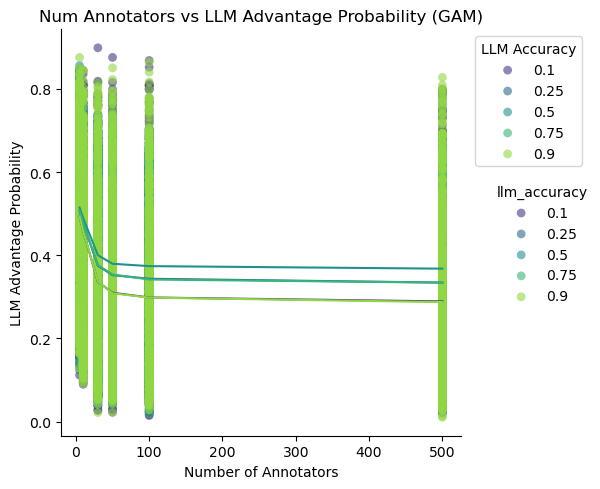

In [19]:
plt.figure(figsize=(10, 6))
sns.lmplot(
    data=results_df,
    x='num_annotators',
    y='advantage_prob',
    hue='llm_accuracy',
    palette='viridis',
    scatter_kws={'alpha': 0.6, 's': 40, 'edgecolor': 'none'},
    line_kws={'linewidth': 1.5},
    lowess=True  # Use locally weighted scatterplot smoothing (GAM-like behavior)
)
plt.xlabel('Number of Annotators')
plt.ylabel('LLM Advantage Probability')
plt.title('Num Annotators vs LLM Advantage Probability (GAM)')
plt.legend(title='LLM Accuracy', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

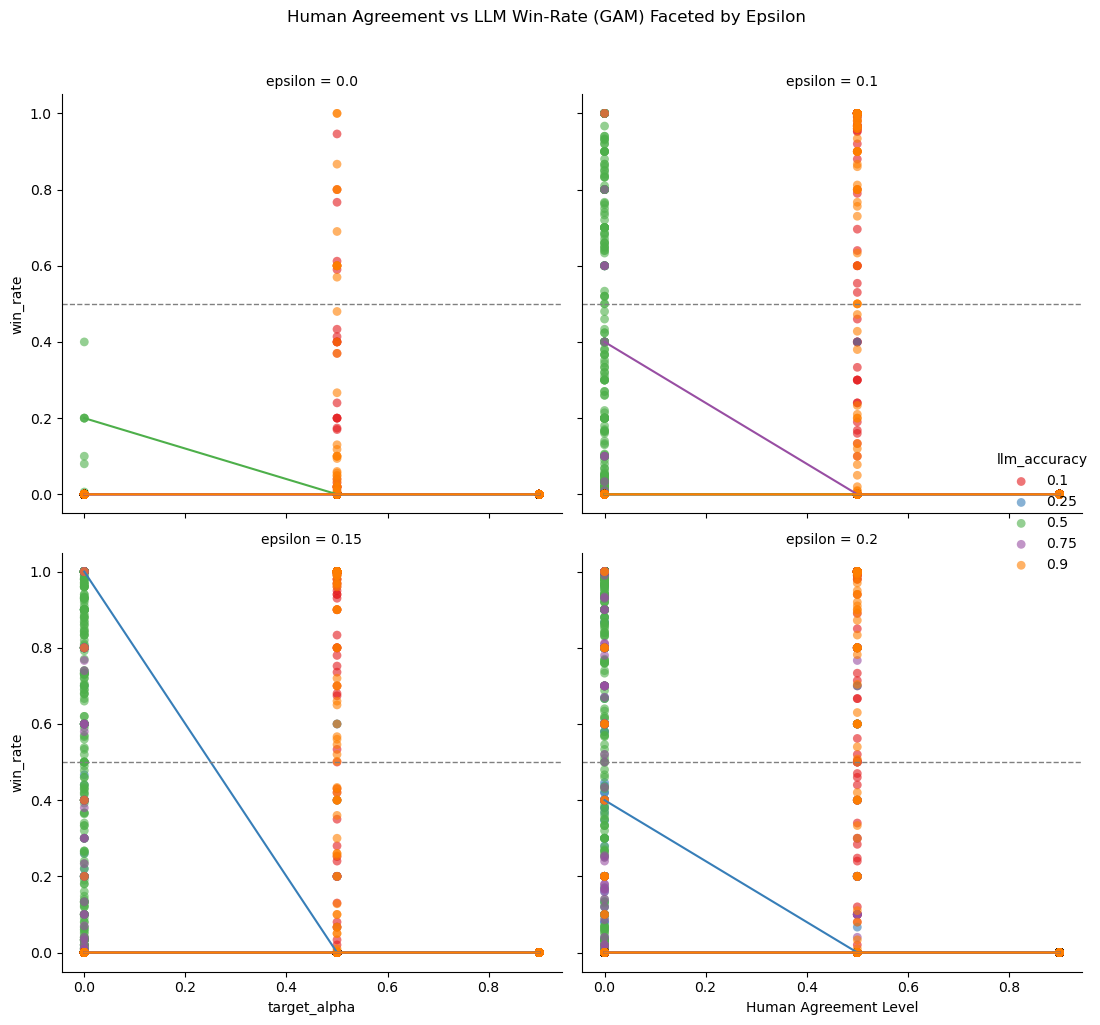

In [21]:
plt.figure(figsize=(10, 6))
g = sns.lmplot(
    data=results_df,
    x='target_alpha',
    y='win_rate',
    hue='llm_accuracy',
    col='epsilon',  # Facet by epsilon
    col_wrap=2,
    palette='Set1',
    scatter_kws={'alpha': 0.6, 's': 40, 'edgecolor': 'none'},
    line_kws={'linewidth': 1.5},
    lowess=True  # Use locally weighted scatterplot smoothing (GAM-like behavior)
)

# Add a horizontal dashed line at y=0.5 for each facet
for ax in g.axes.flat:
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=1)

plt.xlabel('Human Agreement Level')
plt.ylabel('LLM Win Rate')
plt.suptitle('Human Agreement vs LLM Win-Rate (GAM) Faceted by Epsilon', y=1.02)

plt.tight_layout()
plt.show()

In [22]:
np.max(results_df['win_rate'])

1.0

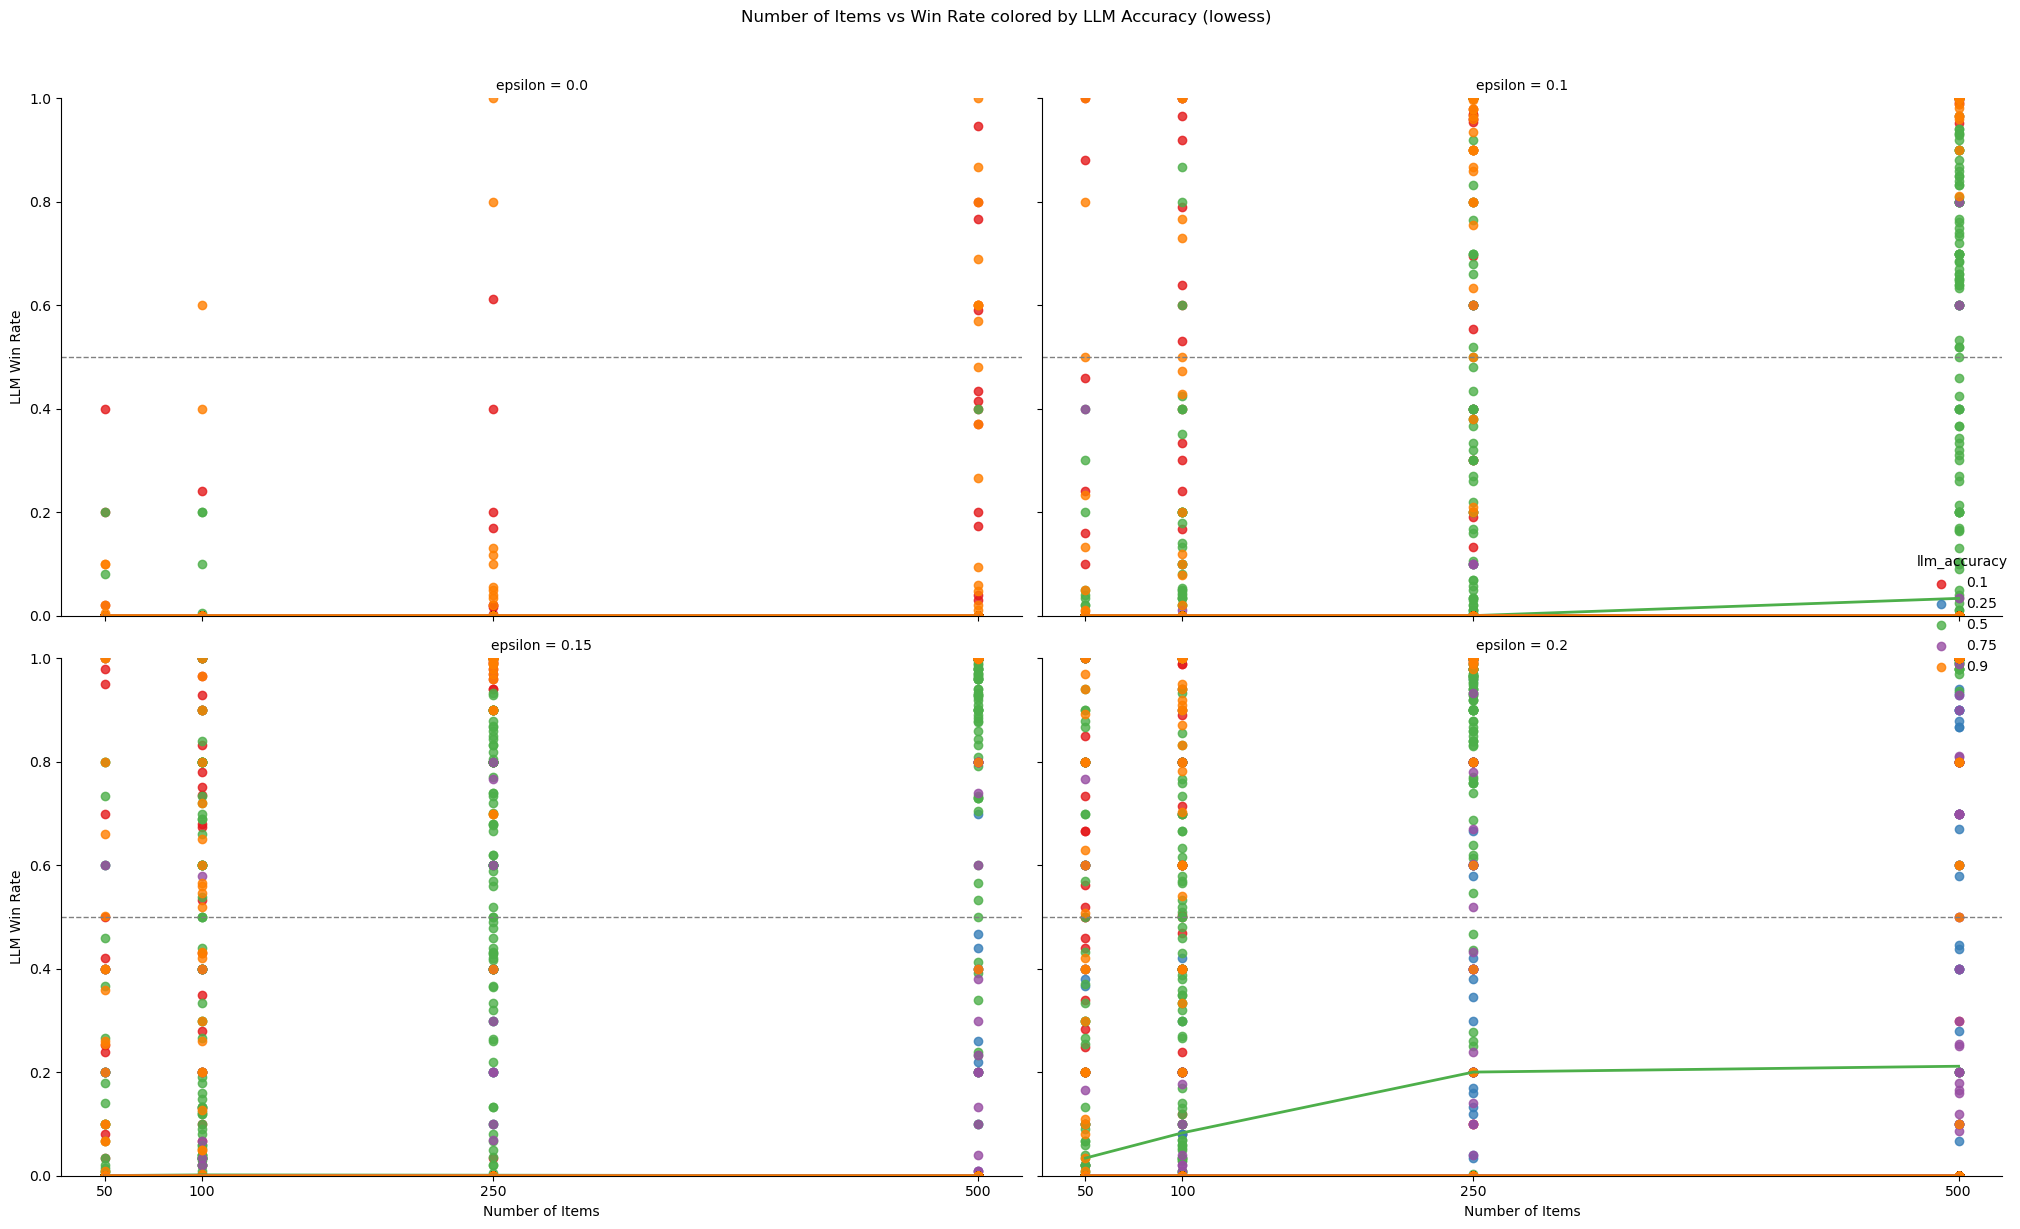

In [23]:
# Scatter: num_items vs win_rate colored by llm_accuracy with GAM (lowess) lines and horizontal 0.5
g = sns.lmplot(
    data=results_df,
    x='num_items',
    y='win_rate',
    hue='llm_accuracy',
    palette='Set1',
    col='epsilon',  # Facet by epsilon
    col_wrap=2,
    # scatter_kws={'alpha': 0.3, 's': 50, 'edgecolor': 'none'},
    line_kws={'linewidth': 2},
    lowess=True,
    height=6,
    aspect=1.6
)

# add horizontal line at 0.5 and format axes
for ax in g.axes.flat:
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=1)
    ax.set_xticks(sorted(results_df['num_items'].unique()))
    ax.set_xlabel('Number of Items')
    ax.set_ylabel('LLM Win Rate')
    ax.set_ylim(0, 1) 

g.fig.suptitle('Number of Items vs Win Rate colored by LLM Accuracy (lowess)', y=1.02)
plt.tight_layout()
plt.show()

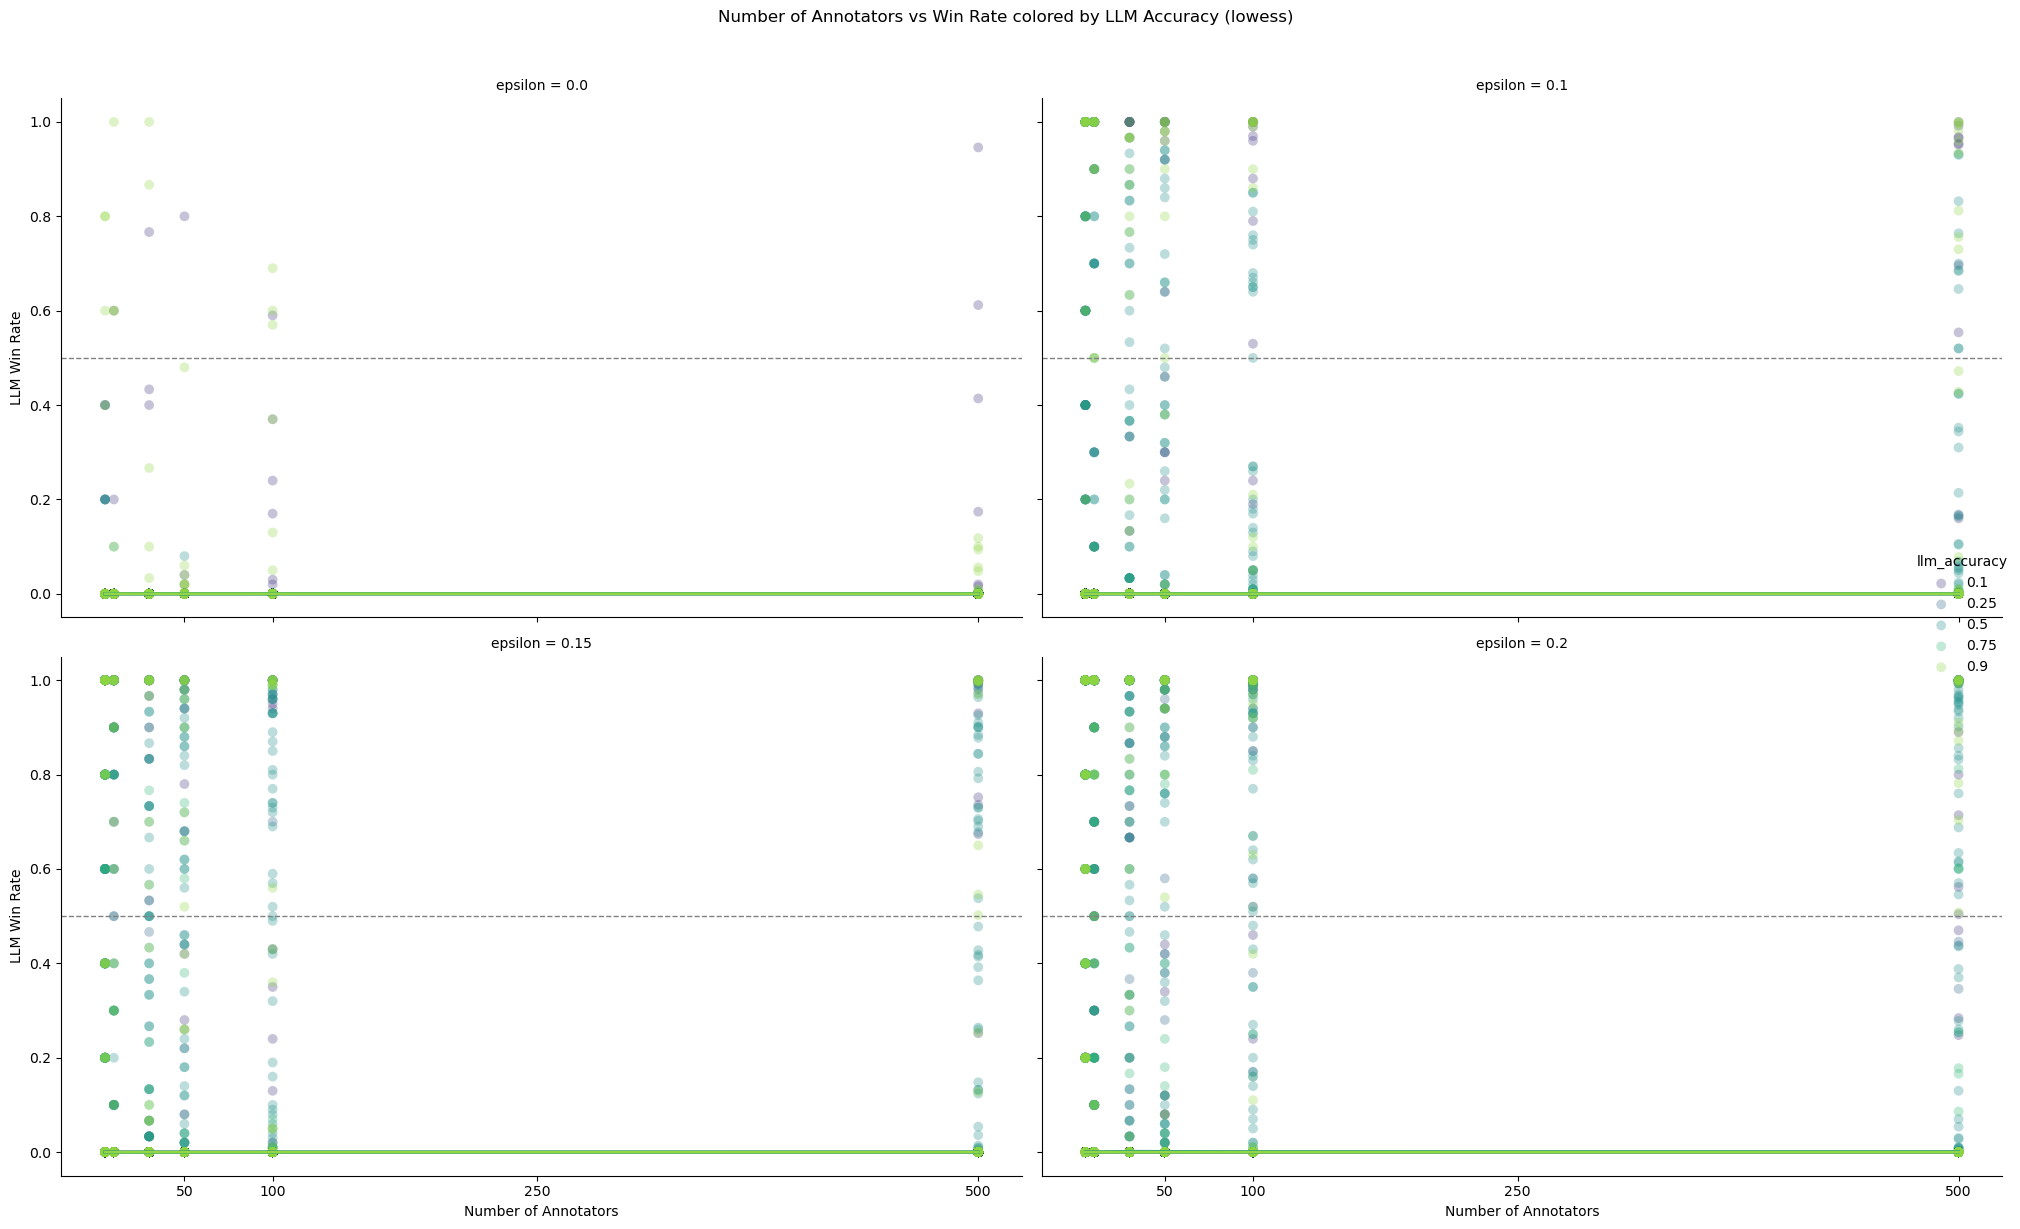

In [24]:
# Scatter: num_items vs win_rate colored by llm_accuracy with GAM (lowess) lines and horizontal 0.5
g = sns.lmplot(
    data=results_df,
    x='num_annotators',
    y='win_rate',
    hue='llm_accuracy',
    palette='viridis',
    col='epsilon',  # Facet by epsilon
    col_wrap=2,
    scatter_kws={'alpha': 0.3, 's': 50, 'edgecolor': 'none'},
    line_kws={'linewidth': 2},
    lowess=True,
    height=6,
    aspect=1.6
)

# add horizontal line at 0.5 and format axes
for ax in g.axes.flat:
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=1)
    ax.set_xticks(sorted(results_df['num_items'].unique()))
    ax.set_xlabel('Number of Annotators')
    ax.set_ylabel('LLM Win Rate')

g.fig.suptitle('Number of Annotators vs Win Rate colored by LLM Accuracy (lowess)', y=1.02)
plt.tight_layout()
plt.show()

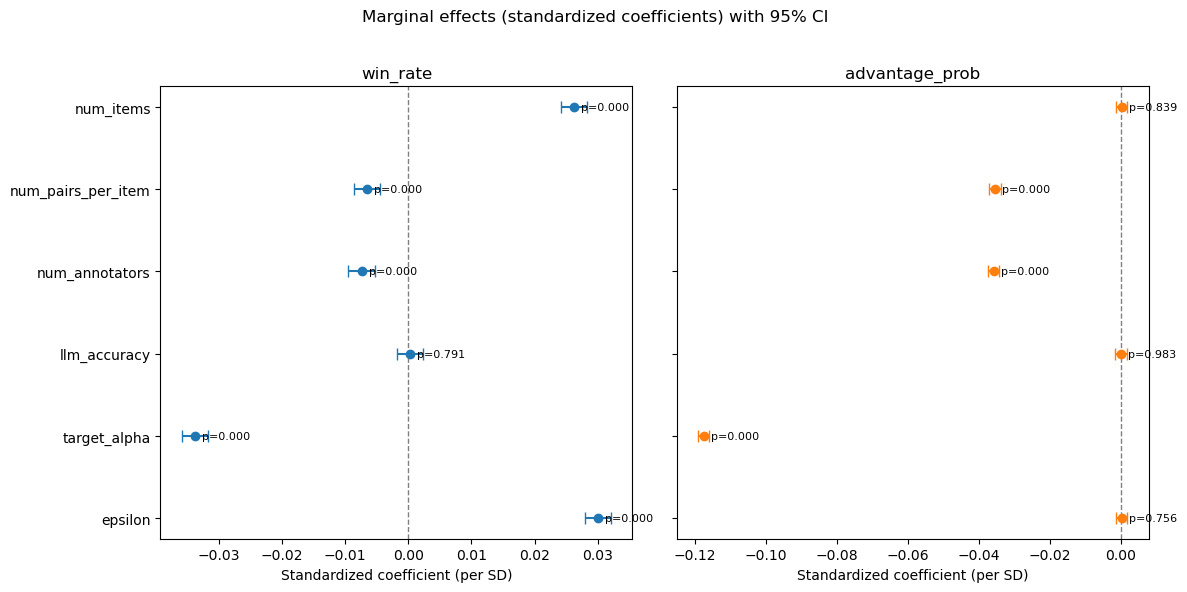

Win rate model R-squared: 0.081
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                0.0433      0.001     40.842      0.000       0.041       0.045
num_items_z              0.0263      0.001     24.787      0.000       0.024       0.028
num_pairs_per_item_z    -0.0065      0.001     -6.171      0.000      -0.009      -0.004
num_annotators_z        -0.0074      0.001     -6.992      0.000      -0.009      -0.005
llm_accuracy_z           0.0003      0.001      0.264      0.791      -0.002       0.002
target_alpha_z          -0.0338      0.001    -31.894      0.000      -0.036      -0.032
epsilon_z                0.0300      0.001     28.338      0.000       0.028       0.032

Advantage probability model R-squared: 0.473
                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------

In [26]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

# Prepare a standardized version of predictors so coefficients are comparable (marginal effects per SD)
predictors = ['num_items', 'num_pairs_per_item', 'num_annotators', 'llm_accuracy',
              'target_alpha', 'epsilon']
df_model = results_df.copy()
for col in predictors:
    df_model[f"{col}_z"] = (df_model[col] - df_model[col].mean()) / df_model[col].std()

formula_rhs = " + ".join([f"{c}_z" for c in predictors])

# Fit OLS models for win_rate and advantage_prob
mod_win = smf.ols(f"win_rate ~ {formula_rhs}", data=df_model).fit()
mod_adv = smf.ols(f"advantage_prob ~ {formula_rhs}", data=df_model).fit()

# Helper to extract terms (exclude Intercept)
def coef_df_from_model(m, outcome_name):
    params = m.params
    ci = m.conf_int()
    pvals = m.pvalues
    rows = []
    for term in params.index:
        if term == "Intercept":
            continue
        rows.append({
            "term": term.replace("_z", ""),
            "coef": params[term],
            "ci_lower": ci.loc[term, 0],
            "ci_upper": ci.loc[term, 1],
            "pval": pvals[term],
            "outcome": outcome_name
        })
    return pd.DataFrame(rows)

coef_win_df = coef_df_from_model(mod_win, "win_rate")
coef_adv_df = coef_df_from_model(mod_adv, "advantage_prob")
coef_df = pd.concat([coef_win_df, coef_adv_df], ignore_index=True)

# Order terms for plotting
term_order = predictors[::-1]  # reverse for nicer vertical ordering

# Dot plot of coefficients with 95% CI, two panels (win_rate, advantage_prob)
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
pal = sns.color_palette("tab10", 2)

for ax, outcome, color in zip(axes, ["win_rate", "advantage_prob"], pal):
    sub = coef_df[coef_df['outcome'] == outcome].set_index('term').reindex(term_order).reset_index()
    ax.errorbar(sub['coef'], range(len(sub)), 
                xerr=[sub['coef'] - sub['ci_lower'], sub['ci_upper'] - sub['coef']],
                fmt='o', color=color, capsize=4)
    ax.axvline(0, color='gray', linestyle='--', linewidth=1)
    ax.set_yticks(range(len(sub)))
    ax.set_yticklabels(sub['term'])
    ax.set_xlabel("Standardized coefficient (per SD)")
    ax.set_title(outcome)
    # Annotate p-values
    for i, pv in enumerate(sub['pval']):
        ax.text(sub['coef'].iloc[i], i, f"  p={pv:.3f}", va='center', fontsize=8)

plt.suptitle("Marginal effects (standardized coefficients) with 95% CI")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Print model summaries (optional quick check)
print("Win rate model R-squared:", round(mod_win.rsquared, 3))
print(mod_win.summary().tables[1])
print("\nAdvantage probability model R-squared:", round(mod_adv.rsquared, 3))
print(mod_adv.summary().tables[1])

The number of items can affect the **alt-test** in several ways:

1. **Statistical Power**:  
   A larger number of items increases the sample size, which improves the statistical power of the test. This allows for more reliable estimates of metrics like win rate and advantage probability, reducing the likelihood of Type I or Type II errors.

2. **Variability in Item Characteristics**:  
   With more items, there is likely to be greater diversity in item characteristics (e.g., complexity, ambiguity). This can influence how well human annotators and LLMs perform, potentially highlighting differences in annotation quality.

3. **Coverage of Annotator Decisions**:  
   More items provide a broader set of comparisons, ensuring that annotators (human or LLM) are evaluated across a wider range of scenarios. This can help identify systematic biases or strengths in annotation strategies.

4. **Pairwise Comparisons**:  
   The number of items directly impacts the number of pairwise comparisons generated. For example, if each item is paired with multiple others, increasing the number of items exponentially increases the number of pairs. This can affect the connectivity and representativeness of the comparison network.

5. **Impact on Dawid-Skene or Scoring Models**:  
   If the alt-test incorporates methods like Dawid-Skene or Bradley-Terry scoring, the number of items influences the reliability of these models. More items typically lead to better estimates of annotator reliability and item scores.

6. **Noise Reduction**:  
   With fewer items, random noise or outliers can disproportionately affect the results. A larger number of items helps average out such effects, leading to more robust conclusions.

In summary, the number of items affects the statistical robustness, diversity, and reliability of the alt-test results.

In [ ]:
results_df.to_csv('alt_test_simulations.csv', index=False)